In [2]:
!pip install mne -q
import mne
print(f"MNE version : {mne.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 52.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
MNE version : 1.12.1


In [3]:
# Téléchargement d'un sujet ERP CORE (paradigme P300 oddball)
from mne.datasets import erp_core

data_path = erp_core.data_path()
print(f"Données téléchargées dans : {data_path}")

Using default location ~/mne_data for erp_core...
Creating /root/mne_data
Fetching 1 file for the erp_core dataset ...


  0%|                                              | 0.00/92.0M [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-ERP-CORE-data.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 13s (87.8 MB)
Données téléchargées dans : /root/mne_data/MNE-ERP-CORE-data


In [4]:
import os

# Explorer ce qui a vraiment été téléchargé
data_path = erp_core.data_path()
for root, dirs, files in os.walk(data_path):
    level = root.replace(str(data_path), '').count(os.sep)
    if level < 3:  # Juste les 3 premiers niveaux
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            for f in files[:3]:  # Premiers fichiers seulement
                print(f'{indent}  {f}')

MNE-ERP-CORE-data/


In [5]:
import os

data_path = erp_core.data_path()
print("Path:", data_path)
print("Contenu:")
for item in os.listdir(data_path):
    print(" ", item)

Path: /root/mne_data/MNE-ERP-CORE-data
Contenu:
  README.txt
  ERP-CORE_Subject-001_Task-Flankers_eeg.fif
  version.txt


In [6]:
raw_file = os.path.join(data_path, 'ERP-CORE_Subject-001_Task-Flankers_eeg.fif')

raw = mne.io.read_raw_fif(raw_file, preload=True)
print(raw.info)

Opening raw data file /root/mne_data/MNE-ERP-CORE-data/ERP-CORE_Subject-001_Task-Flankers_eeg.fif...
    Range : 0 ... 935935 =      0.000 ...   913.999 secs
Ready.
Reading 0 ... 935935  =      0.000 ...   913.999 secs...
<Info | 13 non-empty values
 bads: []
 ch_names: FP1, F3, F7, FC3, C3, C5, P3, P7, P9, PO7, PO3, O1, Oz, Pz, CPz, ...
 chs: 30 EEG, 3 EOG
 custom_ref_applied: True
 dig: 33 items (3 Cardinal, 30 EEG)
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 512.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 33
 projs: []
 sfreq: 1024.0 Hz
 subject_info: <subject_info | sex: 1>
>


Using matplotlib as 2D backend.


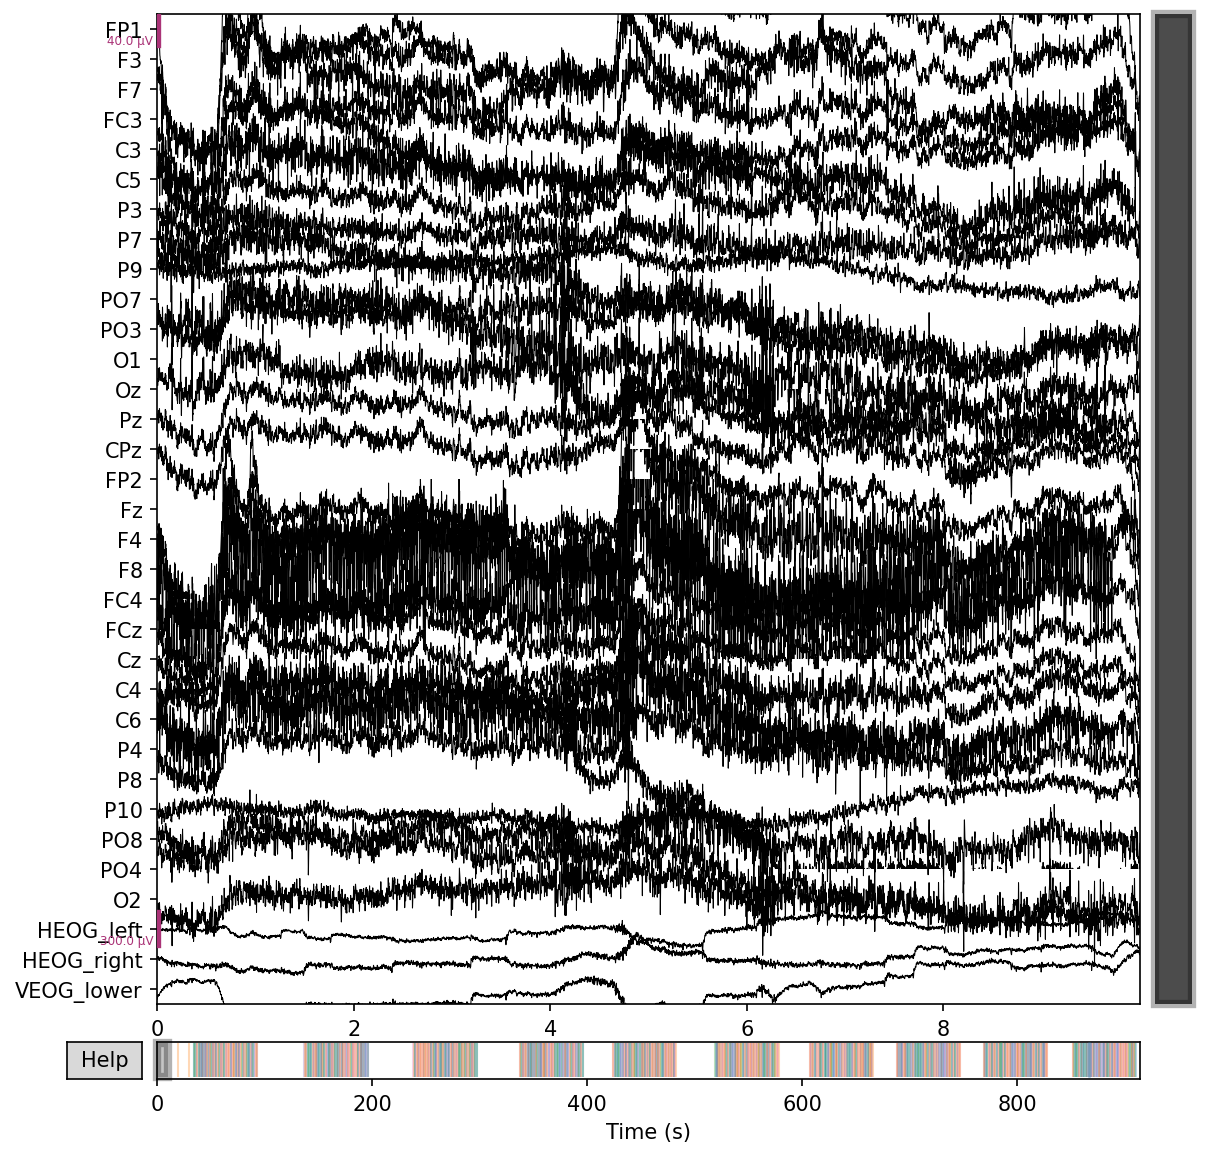

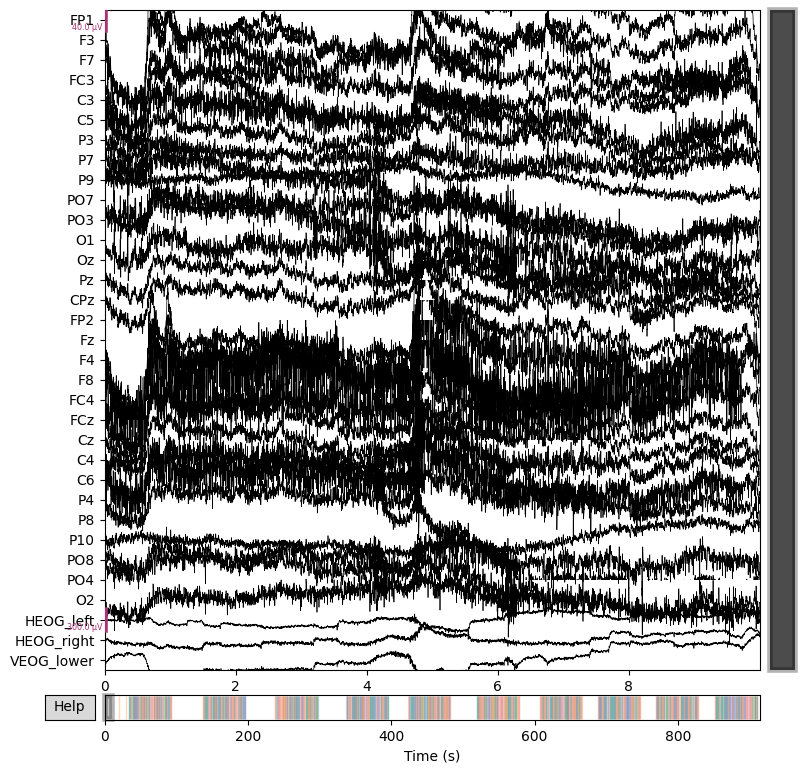

In [7]:
from IPython.display import Image

raw.plot(duration=10, n_channels=33, show=False).savefig('raw_signal.png', dpi=150, bbox_inches='tight')
Image('raw_signal.png')

In [8]:
# Filtre passe-bande : on garde entre 0.1 Hz et 40 Hz
raw_filtered = raw.copy().filter(l_freq=0.1, h_freq=40.0)
print("Filtrage terminé")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33793 samples (33.001 s)

Filtrage terminé


In [9]:
# Lire les événements (marqueurs = timestamps des stimuli)
events, event_id = mne.events_from_annotations(raw_filtered)
print("Types d'événements :", event_id)
print(f"Nombre total d'événements : {len(events)}")

Used Annotations descriptions: [np.str_('response/left'), np.str_('response/right'), np.str_('stimulus/compatible/target_left'), np.str_('stimulus/compatible/target_right'), np.str_('stimulus/incompatible/target_left'), np.str_('stimulus/incompatible/target_right')]
Types d'événements : {np.str_('response/left'): 1, np.str_('response/right'): 2, np.str_('stimulus/compatible/target_left'): 3, np.str_('stimulus/compatible/target_right'): 4, np.str_('stimulus/incompatible/target_left'): 5, np.str_('stimulus/incompatible/target_right'): 6}
Nombre total d'événements : 802


In [11]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id={
        'compatible/left':    3,
        'compatible/right':   4,
        'incompatible/left':  5,
        'incompatible/right': 6
    },
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0),
    reject_by_annotation=True,
    preload=True
)
print(epochs)

Not setting metadata
400 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 400 events and 1025 original time points ...
0 bad epochs dropped
<Epochs | 400 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~103.3 MiB, data loaded,
 'compatible/left': 100
 'compatible/right': 100
 'incompatible/left': 100
 'incompatible/right': 100>


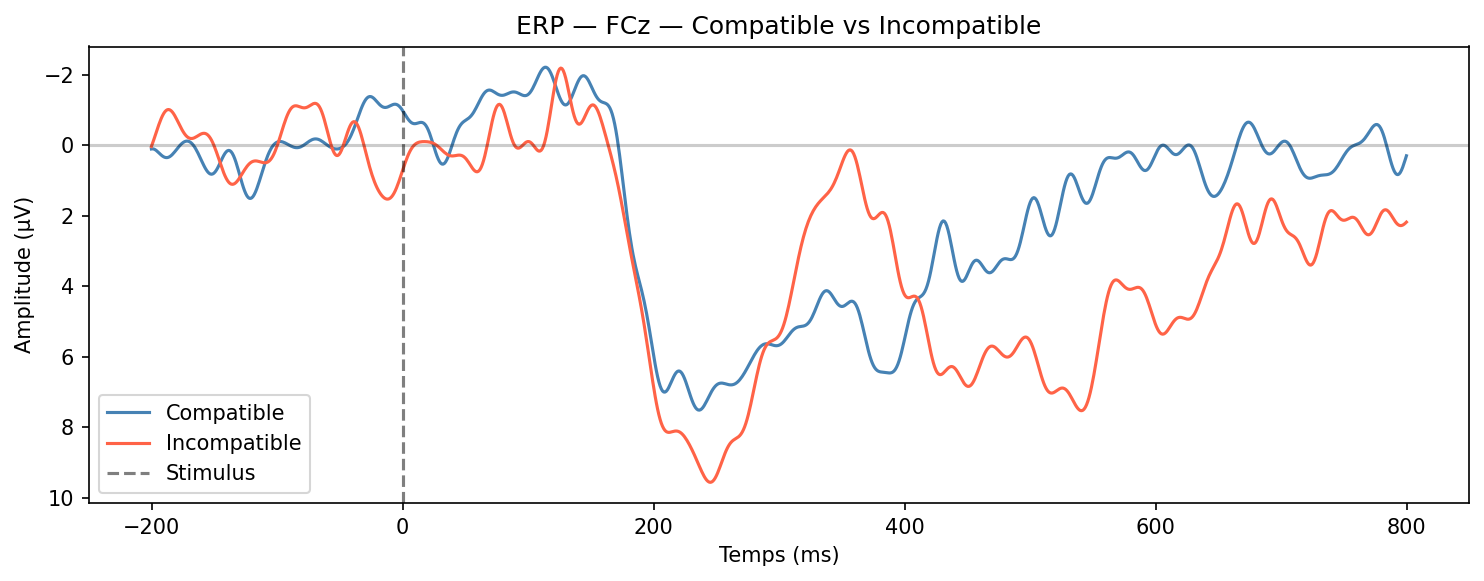

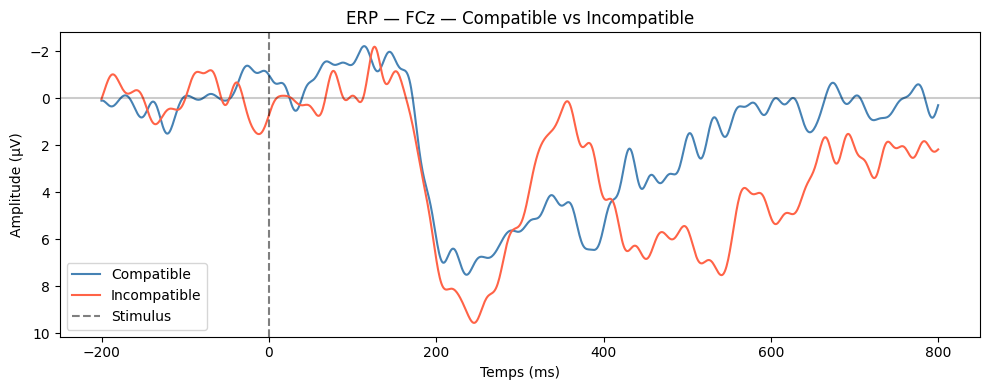

In [13]:
import matplotlib.pyplot as plt
from IPython.display import Image

erp_compatible   = epochs['compatible/left', 'compatible/right'].average()
erp_incompatible = epochs['incompatible/left', 'incompatible/right'].average()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(erp_compatible.times * 1000,
        erp_compatible.get_data(picks='FCz')[0] * 1e6,
        label='Compatible', color='steelblue')

ax.plot(erp_incompatible.times * 1000,
        erp_incompatible.get_data(picks='FCz')[0] * 1e6,
        label='Incompatible', color='tomato')

ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Stimulus')
ax.axhline(0, color='black', linestyle='-', alpha=0.2)
ax.set_xlabel('Temps (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('ERP — FCz — Compatible vs Incompatible')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()

fig.savefig('erp.png', dpi=150, bbox_inches='tight')
Image('erp.png')

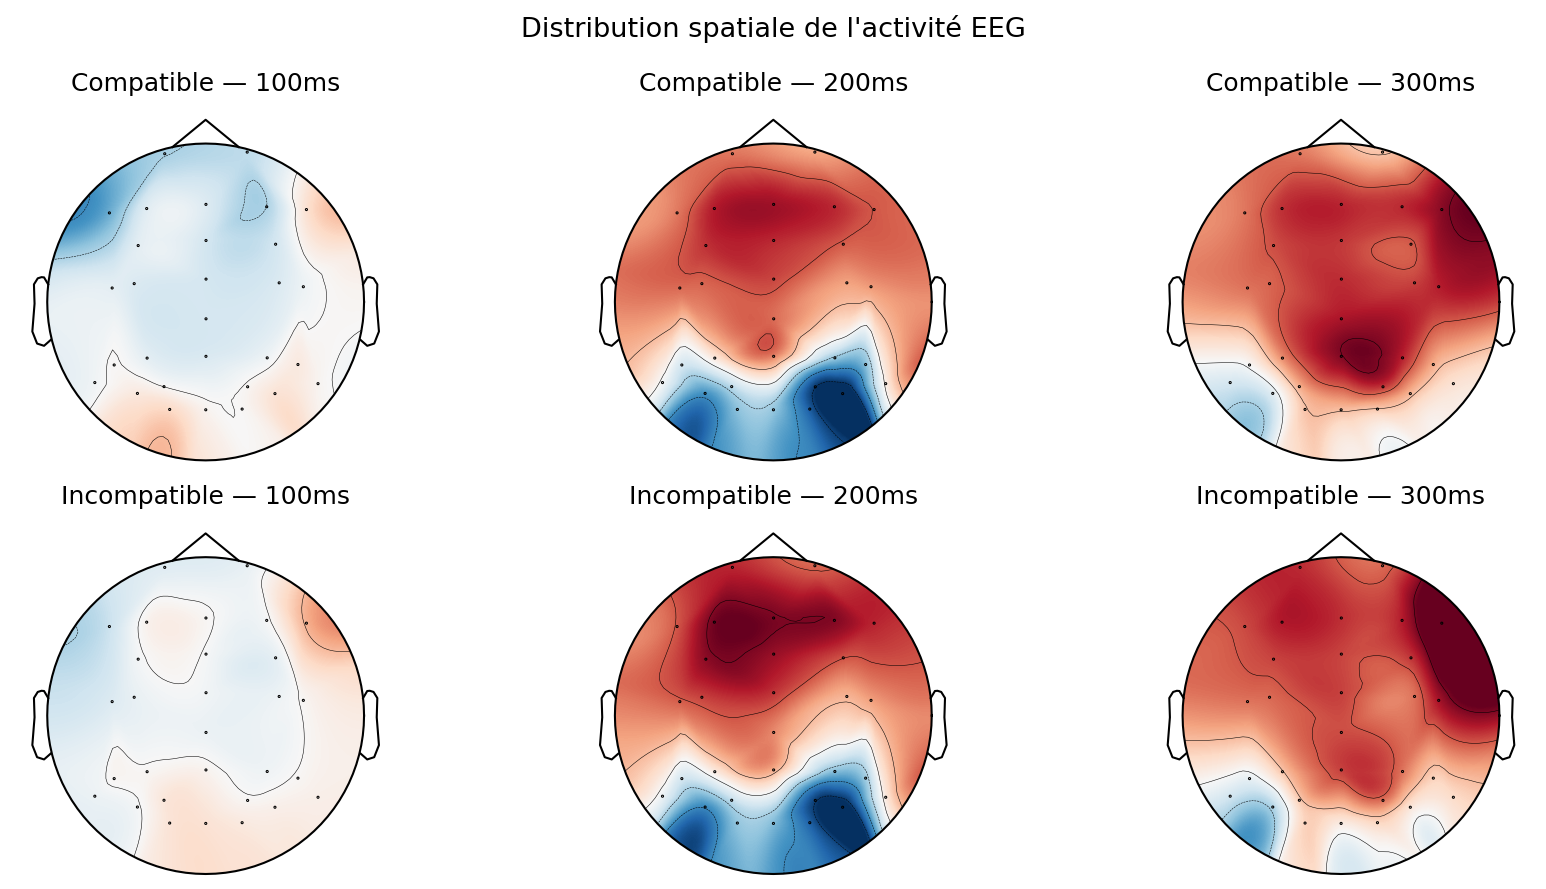

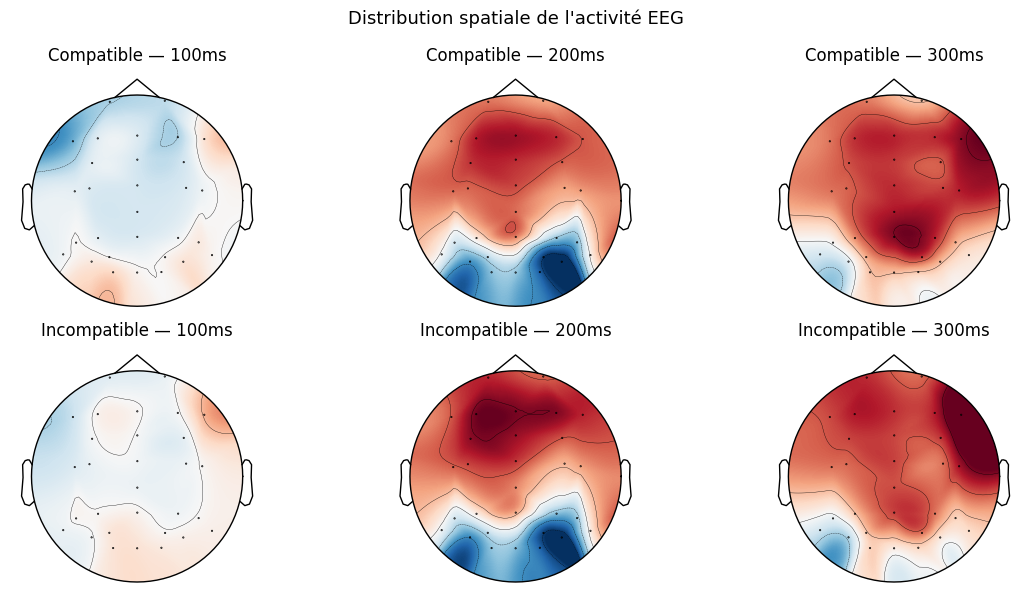

In [14]:
import numpy as np

# Topomap à 3 moments clés : 100ms, 200ms, 300ms
times_to_plot = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i, t in enumerate(times_to_plot):
    erp_compatible.plot_topomap(
        times=t,
        axes=axes[0, i],
        show=False,
        colorbar=False,
        vlim=(-8, 8)
    )
    axes[0, i].set_title(f'Compatible — {int(t*1000)}ms')

    erp_incompatible.plot_topomap(
        times=t,
        axes=axes[1, i],
        show=False,
        colorbar=False,
        vlim=(-8, 8)
    )
    axes[1, i].set_title(f'Incompatible — {int(t*1000)}ms')

plt.suptitle('Distribution spatiale de l\'activité EEG', fontsize=13)
plt.tight_layout()
fig.savefig('topomap.png', dpi=150, bbox_inches='tight')
Image('topomap.png')

In [15]:
from scipy import stats
import numpy as np

# Fenêtre d'intérêt : 150-300ms (pic du N2)
tmin_stat, tmax_stat = 0.15, 0.30

# Extraire les données brutes par trial sur FCz
compat_data   = epochs['compatible/left', 'compatible/right'].copy()
incompat_data = epochs['incompatible/left', 'incompatible/right'].copy()

# Moyenne d'amplitude sur la fenêtre pour chaque trial
def mean_amplitude(ep, tmin, tmax, ch='FCz'):
    ep_crop = ep.copy().crop(tmin=tmin, tmax=tmax)
    idx = ep_crop.ch_names.index(ch)
    return ep_crop.get_data()[:, idx, :].mean(axis=1) * 1e6  # en µV

amp_compat   = mean_amplitude(compat_data,   tmin_stat, tmax_stat)
amp_incompat = mean_amplitude(incompat_data, tmin_stat, tmax_stat)

# T-test indépendant
t_stat, p_val = stats.ttest_ind(amp_compat, amp_incompat)

print(f"Compatible   : M = {amp_compat.mean():.2f} µV  (SD = {amp_compat.std():.2f})")
print(f"Incompatible : M = {amp_incompat.mean():.2f} µV  (SD = {amp_incompat.std():.2f})")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("→ Différence significative ✓")
else:
    print("→ Différence non significative")

Compatible   : M = 4.84 µV  (SD = 8.55)
Incompatible : M = 5.97 µV  (SD = 7.57)
t = -1.397, p = 0.1631
→ Différence non significative
